# Predicción de la Calidad del Vino


# Introducción

La industria vitivinícola depende en gran medida de la evaluación de la calidad del vino, un proceso que históricamente ha recaído en catadores expertos mediante pruebas sensoriales. Sin embargo, este método es subjetivo, costoso y difícil de escalar. La aplicación de técnicas de análisis de datos y modelos de aprendizaje automático abre la posibilidad de predecir la calidad de manera objetiva, reproducible y a gran escala.

En este proyecto se trabaja con el dataset [Wine Quality](https://archive.ics.uci.edu/ml/datasets/wine+quality) (Cortez et al., 2009), que contiene mediciones físico-químicas de vinos tintos y blancos de la región portuguesa del Vinho Verde. Cada muestra incluye variables como el contenido de alcohol, la acidez, los sulfitos y el pH, junto con una puntuación de calidad asignada por sommeliers en una escala del 0 al 10.

El objetivo central es explorar qué variables fisicoquímicas determinan la calidad percibida y construir modelos de clasificación capaces de distinguir vinos de alta calidad de los de calidad estándar. Para ello se comparan tres enfoques: Random Forest, Regresión Logística y XGBoost, evaluando tanto su rendimiento predictivo como la interpretabilidad de los factores que más influyen en la calidad.

# Objetivos

## Objetivo general

Explorar y modelar las variables físico-químicas del dataset Wine Quality para predecir la calidad percibida del vino, identificando los factores que más la determinan.

## Objetivos específicos

* Realizar un análisis exploratorio (EDA) para comprender la distribución de las variables, detectar patrones y comparar el comportamiento de vinos tintos y blancos.

* Identificar y documentar outliers en las variables fisicoquímicas, evaluando su impacto sobre los modelos.

* Construir y comparar tres modelos de clasificación — Random Forest, Regresión Logística y XGBoost — para predecir si un vino es de alta calidad (puntuación ≥ 7).

* Optimizar el modelo de mejor desempeño mediante búsqueda de hiperparámetros (GridSearchCV) y evaluar la ganancia obtenida.

* Interpretar la importancia de las variables en los modelos de árboles para identificar los factores fisicoquímicos más relevantes en la predicción de calidad.

* Evaluar el desbalance de clases del dataset y discutir su efecto sobre los resultados.

# Hipótesis

**Hipótesis 1:** Existe una relación positiva entre el contenido de alcohol y la calidad percibida del vino. Se espera que los vinos con mayor graduación alcohólica reciban puntuaciones más altas por parte de los evaluadores.

**Hipótesis 2:** Variables como la acidez volátil y los sulfatos tienen un impacto significativo en la calidad del vino. La acidez volátil actuaría como predictor negativo (a mayor acidez volátil, menor calidad), mientras que los sulfatos tendrían un efecto positivo moderado.

**Hipótesis 3:** Los modelos de aprendizaje automático basados en árboles de decisión — Random Forest y XGBoost — predicen la calidad del vino con mayor precisión que la Regresión Logística, dado que la relación entre las variables fisicoquímicas y la calidad es no lineal.

# Análisis Exploratorio

In [1]:
# Librerías
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y métricas
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score
import xgboost as xgb
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import GridSearchCV

## Carga y exploración de los datos

### Vino Tinto

In [2]:
# Dataset
red_wine = pd.read_csv("winequality-red.csv", sep=";")

# Exploración de los datos
print("Red Wine:")
print(red_wine.shape)
red_wine.head()

Red Wine:
(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Información general
print("🔎 Información general del vino tinto:")
red_wine.info()

🔎 Información general del vino tinto:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# Verificar si hay valores nulos
print("\n🔍 ¿Hay valores nulos en vino tinto?")
print(red_wine.isnull().sum())


🔍 ¿Hay valores nulos en vino tinto?
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### Vino Blanco

In [5]:
# Datasets
white_wine = pd.read_csv("winequality-white.csv", sep=";")

# Exploración de los datos
print("White Wine:")
print(white_wine.shape)
white_wine.head()

White Wine:
(4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [6]:
# Información general
print("\n🔎 Información general del vino blanco:")
white_wine.info()


🔎 Información general del vino blanco:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [7]:
# Verificar si hay valores nulos
print("\n🔍 ¿Hay valores nulos en vino blanco?")
print(white_wine.isnull().sum())


🔍 ¿Hay valores nulos en vino blanco?
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## Detección y tratamiento de outliers

In [9]:
# Estadísticas descriptivas para vino tinto
print("🍷 Estadísticas vino tinto:")
display(red_wine.describe().T)

# Estadísticas descriptivas para vino blanco
print("\n🥂 Estadísticas vino blanco:")
display(white_wine.describe().T)

🍷 Estadísticas vino tinto:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000



🥂 Estadísticas vino blanco:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


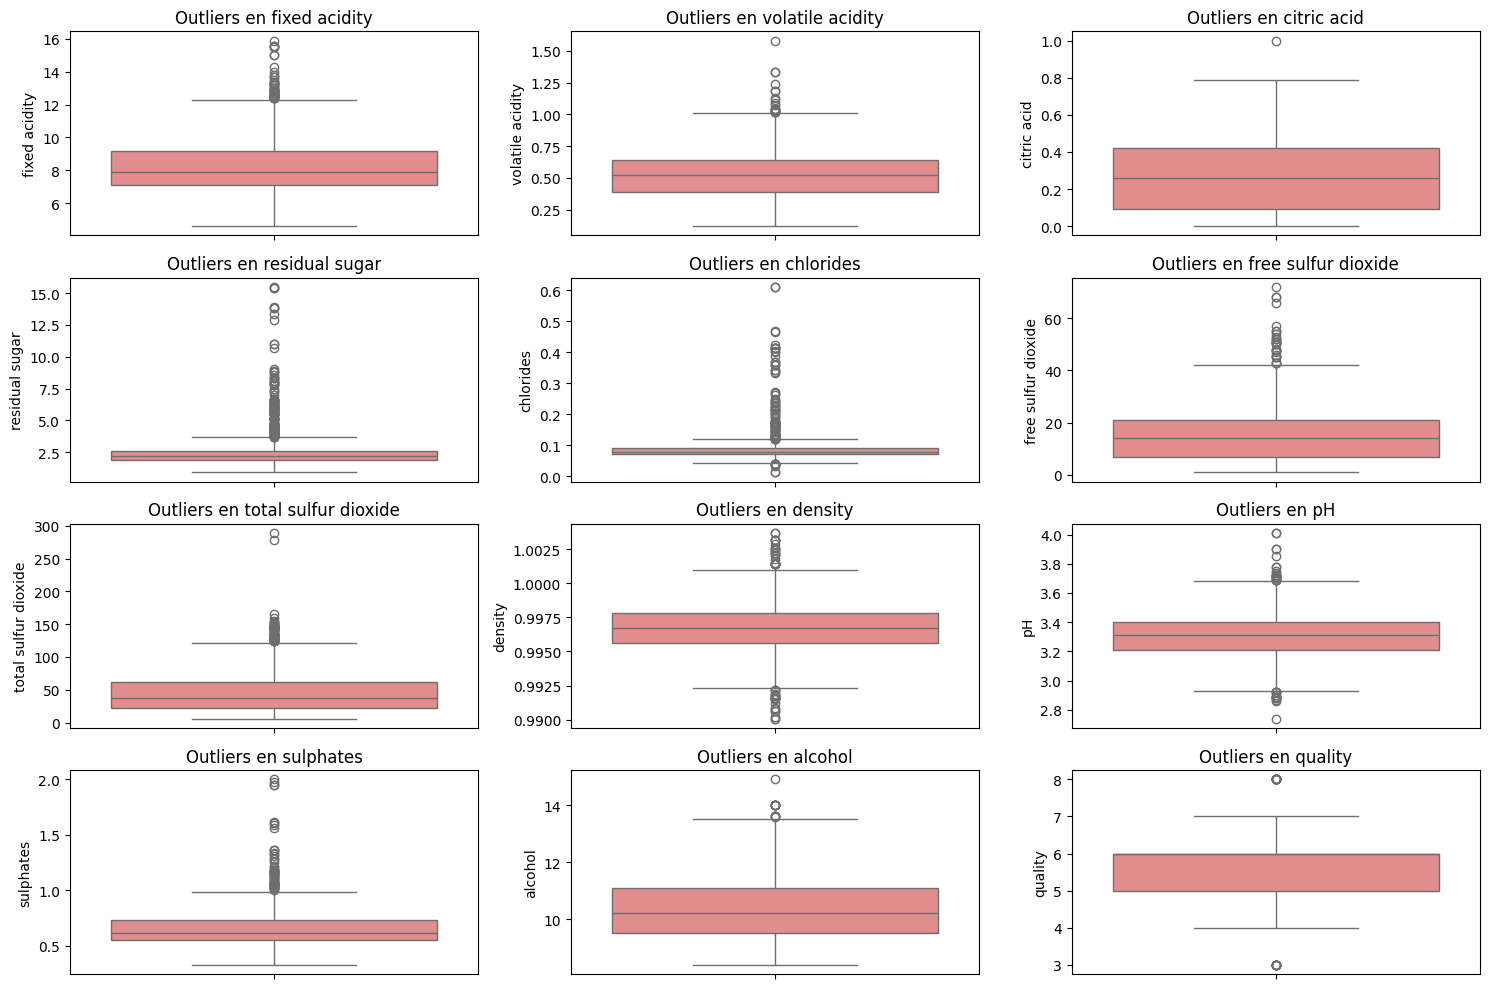

In [ ]:
# Selección de variables numéricas para vino tinto
numeric_cols = red_wine.select_dtypes(include=["float64", "int64"]).columns

# Boxplots para vino tinto
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=red_wine, y=col, color="lightcoral")
    plt.title(f"Outliers en {col}")
plt.tight_layout()
plt.show()

**Análisis de outliers — Vino tinto**

* **Acidez fija (fixed acidity):** Rango habitual entre 6 y 12 g/L. Se detectan outliers por encima de 15 g/L. Corresponden a vinos extremadamente ácidos, posiblemente de terroir particular; son valores válidos pero infrecuentes.

* **Acidez volátil (volatile acidity):** Distribución concentrada entre 0.2 y 0.8 g/L, con outliers por encima de 1.3 g/L. Niveles elevados de ácido acético indican deterioro microbiano o avinagramiento; estos registros merecen revisión ya que pueden distorsionar el modelo.

* **Ácido cítrico (citric acid):** Presenta un número inusual de valores exactamente iguales a 0, lo que puede reflejar un límite de detección del instrumento más que una ausencia real. Los outliers por encima de 0.8 g/L son escasos pero válidos.

* **Azúcar residual (residual sugar):** La gran mayoría de los vinos tintos son secos (valores entre 1.5 y 3 g/L). Los outliers por encima de 4 g/L son pocos y corresponden a vinos semi-secos, que son válidos.

* **Cloratos (chlorides):** Concentración habitual entre 0.05 y 0.12 g/L. Se observan outliers marcados por encima de 0.3 g/L. Valores muy altos pueden indicar contaminación, suelos con alta salinidad o errores de medición; conviene explorarlos antes de modelar.

* **Dióxido de azufre libre (free sulfur dioxide):** Rango típico de 4 a 30 mg/L. Los outliers por encima de 45 mg/L son pocos pero relevantes: concentraciones muy altas generan aromas sulfurosos y pueden influir negativamente en la calidad percibida.

* **Dióxido de azufre total (total sulfur dioxide):** Distribución sesgada a la derecha con outliers por encima de 120 mg/L. En vinos tintos, niveles altos de SO₂ total son infrecuentes; podrían corresponder a vinos con adición excesiva de conservantes.

* **Densidad (density):** Variable muy estable, con casi todos los valores entre 0.993 y 1.000 g/cm³. Los outliers son mínimos y probablemente reflejen variaciones legítimas de composición. No representa un problema para el modelado.

* **pH:** Distribución aproximadamente normal entre 3.1 y 3.7. Los outliers en los extremos (por debajo de 2.9 o por encima de 3.9) son escasos y pueden indicar errores de medición o vinos de características muy particulares.

* **Sulfatos (sulphates):** Rango habitual de 0.45 a 0.90 g/L. Outliers moderados por encima de 1.3 g/L. Los sulfatos actúan como conservante y potenciador aromático; valores muy altos son inusuales pero no necesariamente erróneos.

* **Alcohol (alcohol):** Distribución con pocos outliers. La mayoría de las muestras se ubican entre 9° y 13°, con algunos vinos por encima de 14° que son válidos. Es la variable con mayor correlación con la calidad, por lo que su distribución es especialmente relevante.

* **Calidad (quality):** Variable objetivo discreta en escala del 3 al 8 en el vino tinto (ninguna muestra alcanza el 9). La gran mayoría de las observaciones se concentran en 5 y 6, con muy pocas en los extremos 3 y 8. Este desbalance es la principal limitación del dataset para predecir calidades excepcionales o muy deficientes.

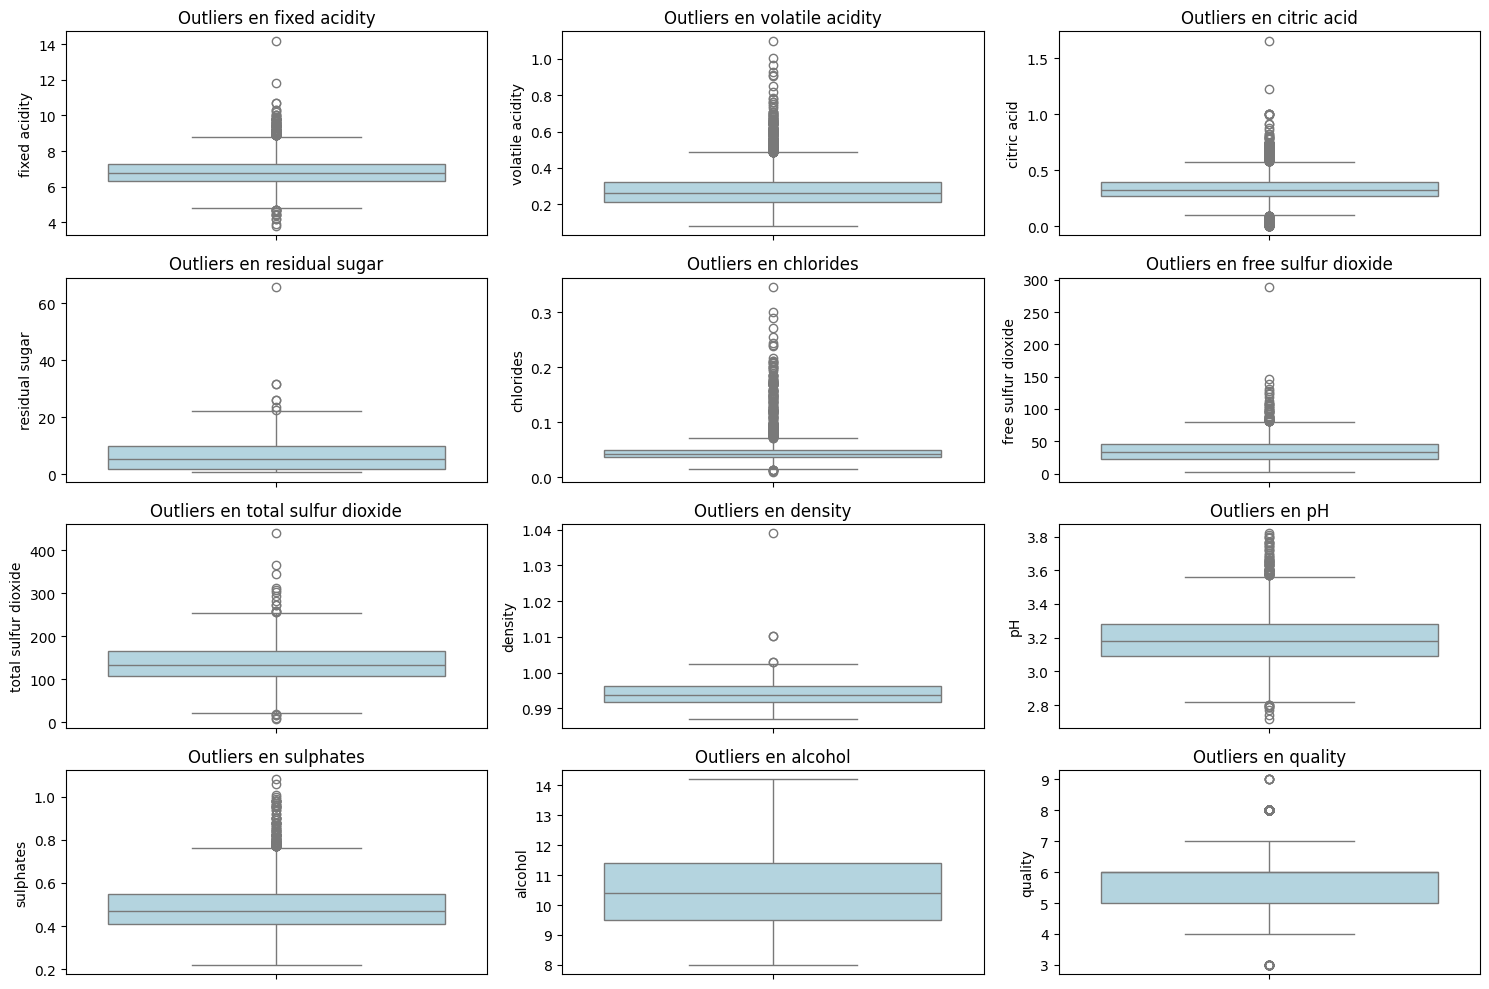

In [11]:
# Selección de variables numéricas para vino blanco
numeric_cols = white_wine.select_dtypes(include=["float64", "int64"]).columns

# Boxplots para vino blanco
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=white_wine, y=col, color="lightblue")
    plt.title(f"Outliers en {col}")
plt.tight_layout()
plt.show()

**Análisis de outliers — Vino blanco**

* **Acidez fija (fixed acidity):** Distribución más concentrada que en el tinto, con pocos outliers. El vino blanco naturalmente presenta menor acidez fija.

* **Acidez volátil (volatile acidity):** Outliers moderados por encima de 0.8. En el blanco los umbrales tolerables son más bajos que en el tinto; valores altos sugieren defectos de fermentación.

* **Ácido cítrico (citric acid):** Algunos valores en cero, pero más raros que en el tinto. Los outliers altos son excepcionales y válidos.

* **Azúcar residual (residual sugar):** Variable con mayor dispersión del dataset. Los outliers extremos (>40 g/L) corresponden a vinos dulces o semi-dulces, que son perfectamente legítimos pero forman una distribución bimodal característica del blanco.

* **Cloratos (chlorides):** Outliers por encima de 0.1 g/L. El vino blanco suele tener menor concentración de cloruros; valores altos pueden indicar contaminación o terroir particular.

* **Dióxido de azufre libre (free sulfur dioxide):** Outliers más pronunciados que en el tinto, reflejo del mayor uso de SO₂ como conservante en blancos. Valores extremos (>100 mg/L) pueden generar aromas sulfurosos.

* **Dióxido de azufre total (total sulfur dioxide):** Distribución muy sesgada a la derecha con outliers marcados. Es esperable en blancos jóvenes con alta adición de sulfitos.

* **Densidad (density):** Muy pocos outliers; variable estable que correlaciona con el azúcar residual y el alcohol.

* **pH:** Distribución concentrada entre 3.0 y 3.5. Outliers menores en ambos extremos; el blanco tiende a ser más ácido (pH más bajo) que el tinto.

* **Sulfatos (sulphates):** Rango más estrecho que en el tinto. Los outliers son leves y no representan un problema significativo.

* **Alcohol (alcohol):** Distribución con leve sesgo positivo. Los outliers por encima de 14° son poco frecuentes pero válidos.

* **Calidad (quality):** Variable objetivo discreta (escala 3–9). Sin outliers reales; la baja frecuencia de puntuaciones extremas (3 y 9) refleja el desbalance de clases del dataset.

## Union de los datasets

In [12]:
# Nueva columna con el tipo de vino
red_wine["wine_type"] = "Red"
white_wine["wine_type"] = "White"

# Unión de los datasets
wine = pd.concat([red_wine, white_wine], axis=0).reset_index(drop=True)

# Verificación
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Red


## Comparación gráfica de variables

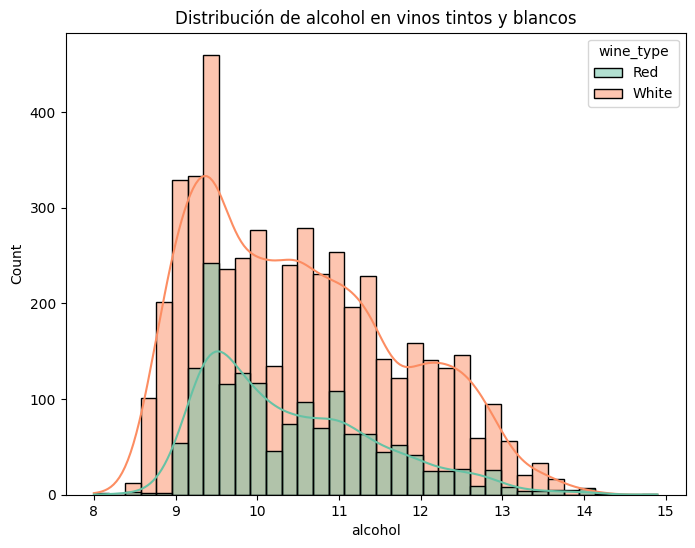

In [13]:
# Histograma de alcohol por tipo de vino
plt.figure(figsize=(8, 6))
sns.histplot(data=wine, x="alcohol", hue="wine_type", kde=True, palette="Set2", alpha=0.5)
plt.title("Distribución de alcohol en vinos tintos y blancos")
plt.show()

**Análisis**

Ambos tipos de vino comparten un rango de alcohol similar (entre 8° y 15°), pero sus distribuciones difieren en forma y centro. Los vinos blancos presentan una distribución más concentrada en torno a los 9–10°, con una curva KDE más estrecha. Los vinos tintos muestran mayor dispersión y una mediana ligeramente más alta.

Cabe destacar que el dataset contiene considerablemente más muestras de vino blanco que de tinto, lo que genera un desbalance que debe tenerse en cuenta al interpretar los análisis comparativos y al evaluar el desempeño de los modelos.

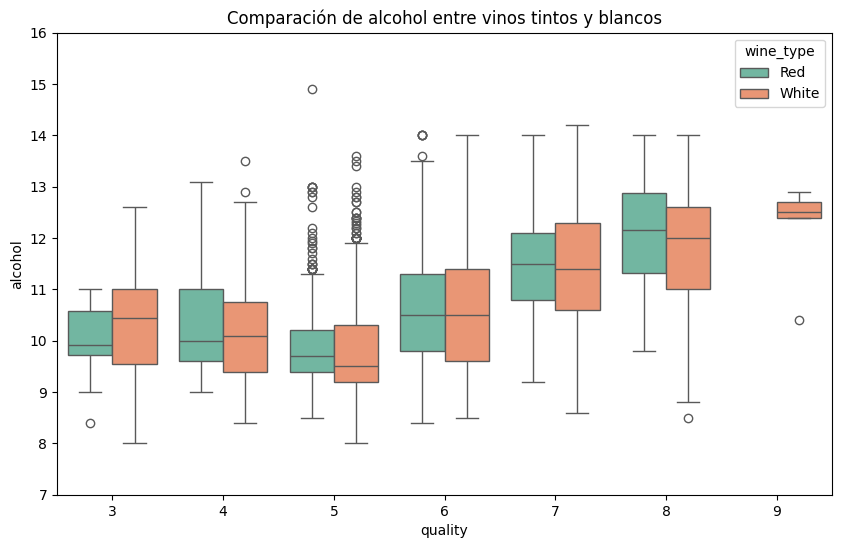

In [14]:
# Boxplot de alcohol por calidad y tipo de vino
f, ax = plt.subplots(figsize=(10, 6))
fig = sns.boxplot(x="quality", y="alcohol", data=wine, hue= "wine_type", palette="Set2")
fig.axis(ymin=7, ymax=16)
plt.title("Comparación de alcohol entre vinos tintos y blancos")
plt.show()

**Análisis**

El boxplot muestra una tendencia clara y consistente en ambos tipos de vino: a medida que aumenta la puntuación de calidad, la mediana del contenido de alcohol sube progresivamente. Los vinos de calidad 7 y 8 presentan medianas por encima de los 11.5°, mientras que los de calidad 4 y 5 se ubican por debajo de los 10.5°.

Esta evidencia confirma la **hipótesis 1**: existe una relación positiva entre el contenido de alcohol y la calidad percibida. No obstante, la superposición de los rangos intercuartílicos en calidades medias (5–6) indica que el alcohol no es el único factor determinante; otros predictores son necesarios para discriminar dentro de ese rango.

Text(0.5, 1.0, 'Alcohol vs Calidad por Tipo de Vino')

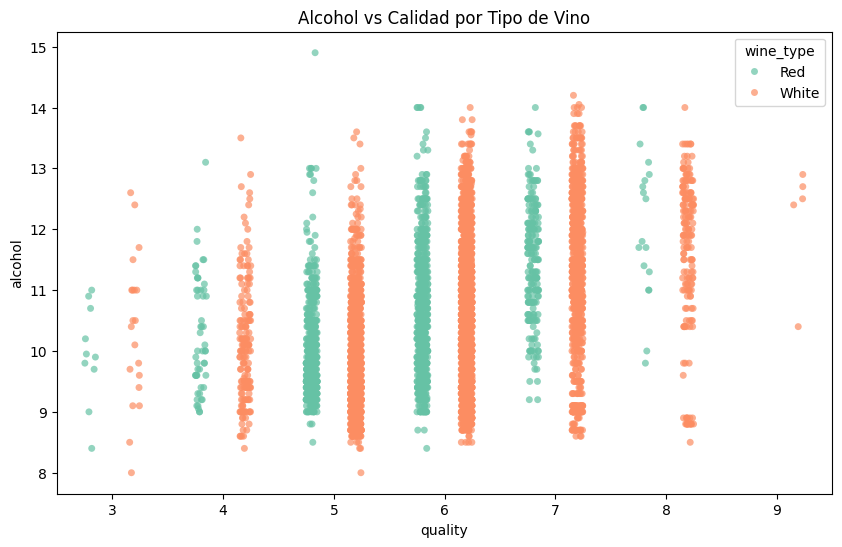

In [15]:
# Stripplot de alcohol por calidad y tipo de vino
plt.figure(figsize=(10, 6))
sns.stripplot(data=wine, x="quality", y="alcohol", hue="wine_type", dodge=True, palette="Set2", alpha=0.7)
plt.title("Alcohol vs Calidad por Tipo de Vino")

**Análisis**

El stripplot complementa el boxplot anterior mostrando la densidad real de observaciones. Se confirma la tendencia positiva entre alcohol y calidad: los vinos de mayor puntuación (7–8) concentran sus puntos en la franja de 11–13° de alcohol. En calidades medias (5–6), que agrupan la mayor parte del dataset, la dispersión es amplia, indicando que el alcohol por sí solo no determina la calidad en ese rango. Las calidades extremas (3 y 9) tienen muy pocas muestras, lo que refuerza la necesidad de considerar técnicas de balanceo de clases al modelar.

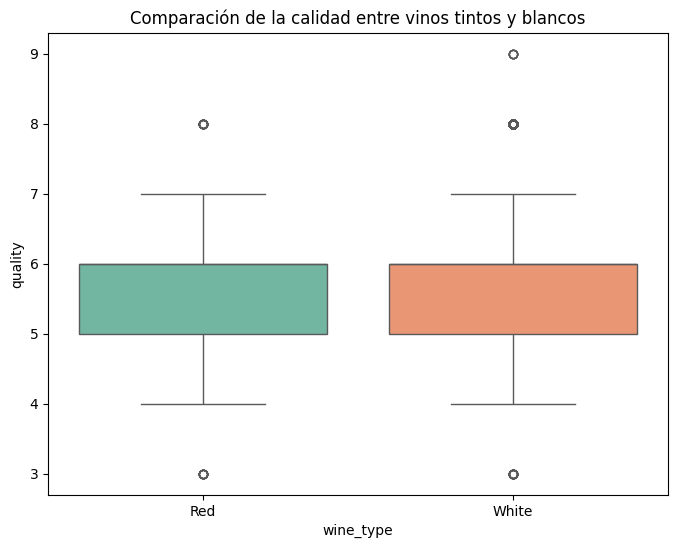

In [16]:
# Boxplot de calidad por tipo de vino
plt.figure(figsize=(8, 6))
sns.boxplot(data=wine, x="wine_type", y="quality", hue= "wine_type", palette="Set2")
plt.title("Comparación de la calidad entre vinos tintos y blancos")
plt.show()

**Análisis**

Las distribuciones de calidad son muy similares entre vinos tintos y blancos: ambos tipos concentran la mayoría de sus muestras en las puntuaciones 5 y 6, con medianas idénticas o muy cercanas. Ninguno de los dos tipos muestra una ventaja sistemática en calidad percibida.

Sin embargo, existen diferencias sutiles: los vinos blancos presentan una mayor cantidad de muestras con puntuación 8 y 9, mientras que los tintos tienen una cola inferior algo más pronunciada. Esto podría reflejar diferencias en los estándares de calidad del Vinho Verde según el tipo, más que una diferencia real en calidad promedio.

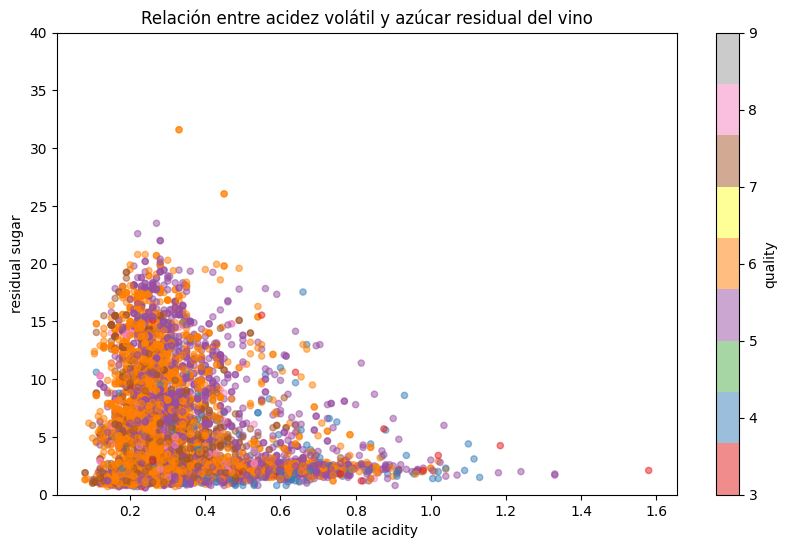

In [17]:
# Scatter plot de acidez volátil vs azúcar residual, coloreado por tipo de vino
wine.plot.scatter(x='volatile acidity', y='residual sugar', c='quality', colormap='Set1', alpha=0.5, figsize=(10, 6), ylim=(0, 40))
plt.title("Relación entre acidez volátil y azúcar residual del vino")
plt.show()

**Análisis**

El scatter muestra que la acidez volátil y el azúcar residual presentan comportamientos muy distintos según el tipo de vino. Los vinos blancos concentran valores de azúcar residual considerablemente más altos, coherente con su perfil de producción. En cuanto a la calidad (escala de color), se observa que los vinos con menor acidez volátil tienden a tener puntuaciones más altas, lo que comienza a confirmar la **hipótesis 2**: la acidez volátil tiene un impacto negativo en la calidad percibida. La relación entre azúcar residual y calidad no es lineal ni clara en este gráfico, sugiriendo que su efecto depende más del tipo de vino.

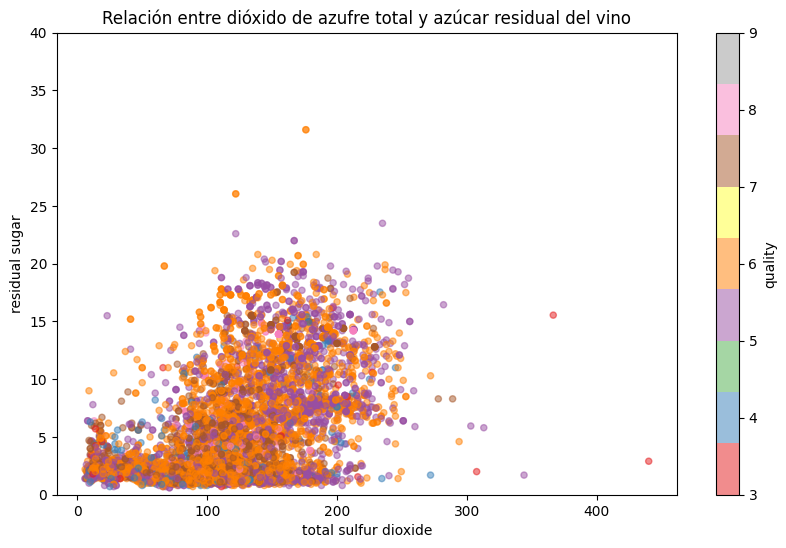

In [18]:
# Scatter plot de dióxido de azufre total vs azúcar residual, coloreado por tipo de vino
wine.plot.scatter(x='total sulfur dioxide', y='residual sugar', c='quality', colormap='Set1', alpha=0.5, figsize=(10, 6), ylim=(0, 40))
plt.title("Relación entre dióxido de azufre total y azúcar residual del vino")
plt.show()

**Análisis**

Se observa una fuerte separación entre vinos tintos y blancos: los blancos presentan niveles de dióxido de azufre total y azúcar residual marcadamente más elevados, lo que refleja diferencias en los procesos de elaboración y conservación. En los tintos, ambas variables se mantienen en rangos bajos y compactos. La calidad no muestra un patrón claro respecto al SO₂ total, lo que sugiere que esta variable actúa más como indicador del proceso de vinificación que como predictor directo de la calidad percibida.

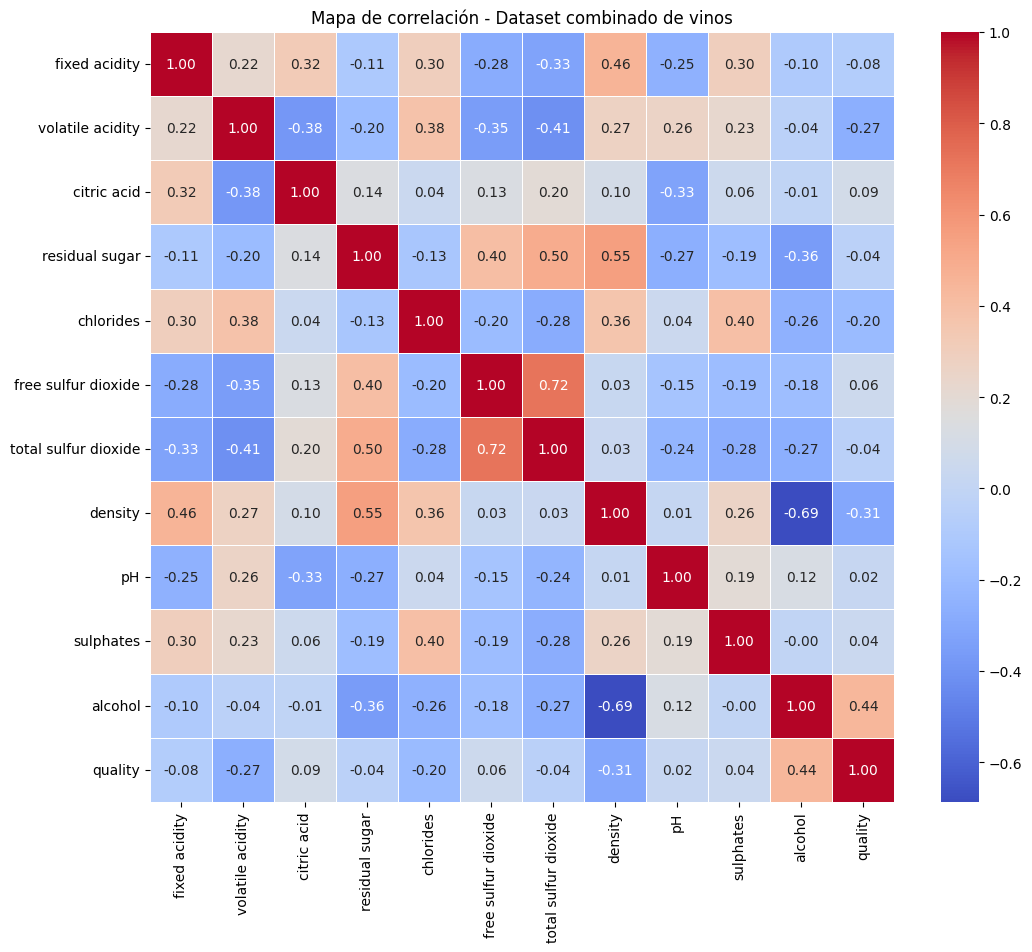

In [ ]:
# Mapa de correlación para vinos combinados
plt.figure(figsize=(12, 10))
correlation = wine.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de correlación - Dataset combinado de vinos")
plt.show()

**Análisis**

El mapa de correlación general (ambos tipos de vino combinados) revela las asociaciones más relevantes del dataset:

- **Alcohol ↔ Calidad (+0.44):** La correlación positiva más fuerte con la variable objetivo. Confirma la hipótesis 1.
- **Acidez volátil ↔ Calidad (−0.27):** Relación negativa moderada. A mayor acidez volátil, menor calidad percibida.
- **Densidad ↔ Alcohol (−0.69):** Correlación fuerte esperada: mayor concentración de alcohol implica menor densidad del líquido.
- **Azúcar residual ↔ Densidad (+0.55):** Los vinos más dulces tienen mayor densidad, coherente con la física del líquido.
- **SO₂ libre ↔ SO₂ total (+0.72):** Alta colinealidad entre ambas variables de sulfitos. Podría justificar eliminar una de las dos al modelar.

En general, las correlaciones son moderadas, lo que indica que la calidad es un fenómeno multivariado que requiere modelos no lineales para capturarse bien.

In [20]:
# Filtrar
red_wine_only = wine[wine["wine_type"] == "Red"]
white_wine_only = wine[wine["wine_type"] == "White"]

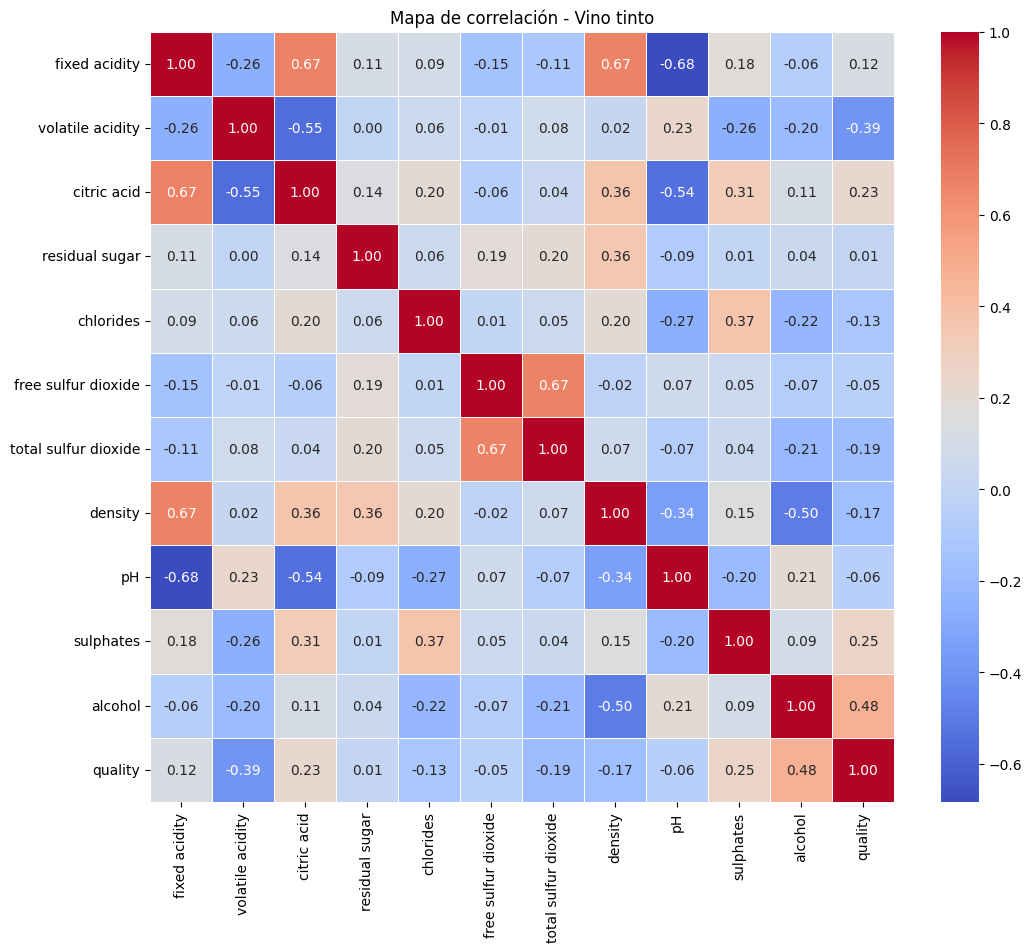

In [ ]:
# Mapa de correlación para vino tinto
plt.figure(figsize=(12, 10))
corr_red = red_wine_only.corr(numeric_only=True)

sns.heatmap(corr_red, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de correlación - Vino tinto")
plt.show()

**Correlaciones más relevantes en vino tinto:**

- **Alcohol ↔ Calidad (+0.48):** Correlación positiva más fuerte que en el dataset combinado. El alcohol es el predictor individual más importante para la calidad en el tinto.
- **Acidez volátil ↔ Calidad (−0.39):** Relación negativa clara. En el vino tinto, la acidez volátil es un indicador de deterioro más marcado que en el blanco, por lo que su impacto sobre la calidad percibida es mayor.
- **Sulfatos ↔ Calidad (+0.25):** Correlación positiva moderada. Los sulfatos actúan como conservante y pueden potenciar la intensidad aromática, mejorando la percepción de calidad en tintos.
- **Densidad ↔ Alcohol (−0.50):** Correlación negativa esperada; a mayor alcohol, menor densidad del líquido.
- **Acidez fija ↔ Densidad (+0.67):** Alta colinealidad; la acidez fija aumenta la densidad del vino.
- **Acidez fija ↔ pH (−0.68):** Relación inversa consistente con la química: mayor acidez fija implica menor pH.

En el vino tinto, la calidad está más determinada por variables relacionadas con la fermentación y la conservación (alcohol, acidez volátil, sulfatos) que por las variables de dulzor o cuerpo.

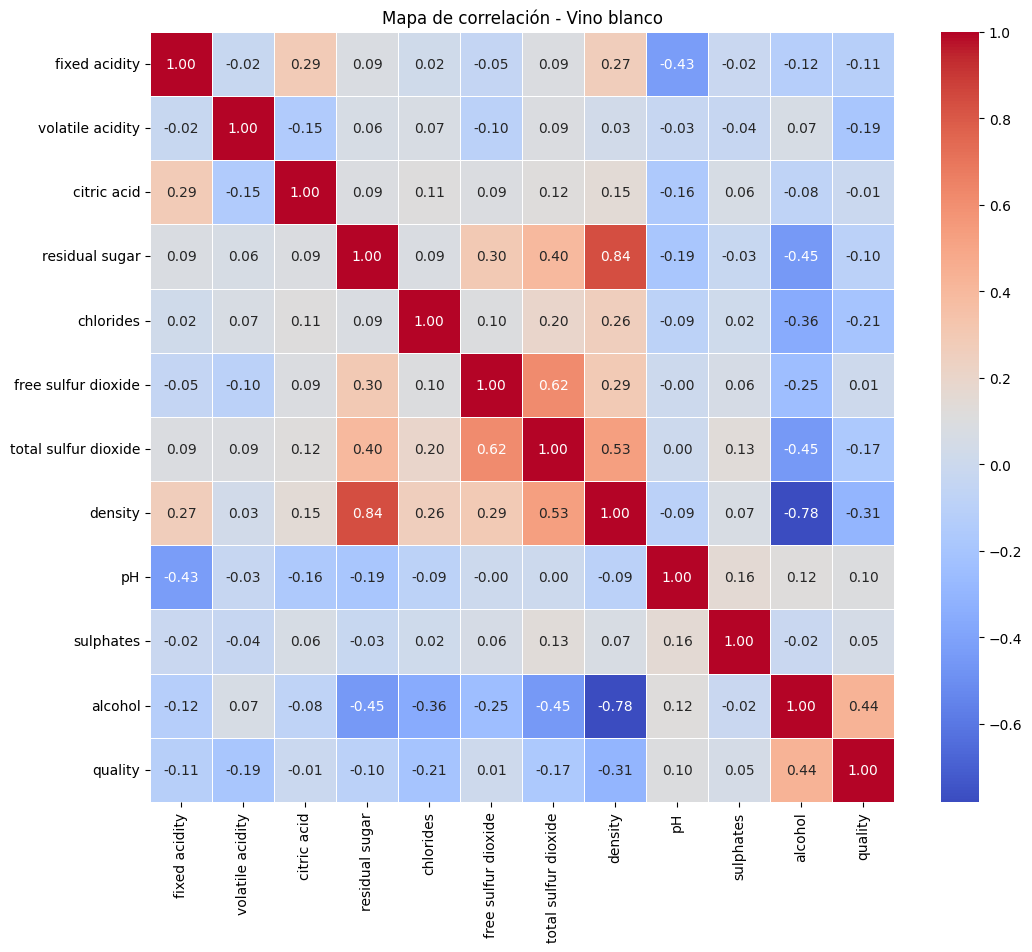

In [ ]:
# Mapa de correlación para vino blanco
plt.figure(figsize=(12, 10))
corr_white = white_wine_only.corr(numeric_only=True)

sns.heatmap(corr_white, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de correlación - Vino blanco")
plt.show()

**Correlaciones más relevantes en vino blanco:**

- **Alcohol ↔ Calidad (+0.44):** Correlación positiva similar al dataset general. El alcohol sigue siendo el predictor más fuerte de calidad, aunque algo menos pronunciado que en el tinto.
- **Densidad ↔ Calidad (−0.31):** Correlación negativa más marcada que en el tinto. En los blancos, los vinos más densos (con más azúcar residual) tienden a recibir menor puntuación, lo que puede reflejar la preferencia por vinos secos en la escala de calificación.
- **Densidad ↔ Azúcar residual (+0.84):** Correlación muy alta, la más fuerte del mapa. El azúcar residual es el principal determinante de la densidad en los vinos blancos.
- **Densidad ↔ Alcohol (−0.78):** Correlación negativa más fuerte que en el tinto, coherente con el mayor rango de variación del azúcar y el alcohol en blancos.
- **SO₂ libre ↔ SO₂ total (+0.62):** Alta colinealidad entre ambas variables de sulfitos, lo que puede justificar usar solo una de ellas como predictora.
- **Acidez volátil ↔ Calidad (−0.19):** Impacto negativo menor que en el tinto, lo que sugiere que en los blancos otros factores pesan más en la percepción de calidad.

El mapa del vino blanco refleja una química más compleja que el tinto, con mayor protagonismo del azúcar residual y la densidad, variables que en el tinto son relativamente neutras.

# Modelos - Entrenamiento de algoritmos

## Preparación de las variables

In [23]:
# Creación de una nueva columna binaria
wine["high_quality"] = (wine["quality"] >= 7).astype(int)

# Verificamos proporciones
wine["high_quality"].value_counts(normalize=True)

high_quality
0    0.803448
1    0.196552
Name: proportion, dtype: float64

In [24]:
# Variables numéricas
features = wine.drop(columns=["quality", "high_quality", "wine_type"]).select_dtypes(include=["float64", "int64"])

X = features
y = wine["high_quality"]

In [25]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## Modelo Random Forest Classifier

In [ ]:
# Crear y entrenar el modelo
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_pred_rf_proba = model.predict_proba(X_test)[:, 1]

In [27]:
# Métricas
print("Clasificación - Random Forest:\n")
print(classification_report(y_test, y_pred))

Clasificación - Random Forest:

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1567
           1       0.79      0.54      0.64       383

    accuracy                           0.88      1950
   macro avg       0.84      0.75      0.79      1950
weighted avg       0.88      0.88      0.87      1950



In [28]:
# Matriz de confusión
print("Matriz de Confusión:\n")
print(confusion_matrix(y_test, y_pred))

Matriz de Confusión:

[[1512   55]
 [ 175  208]]


### Importancia de variables — Random Forest

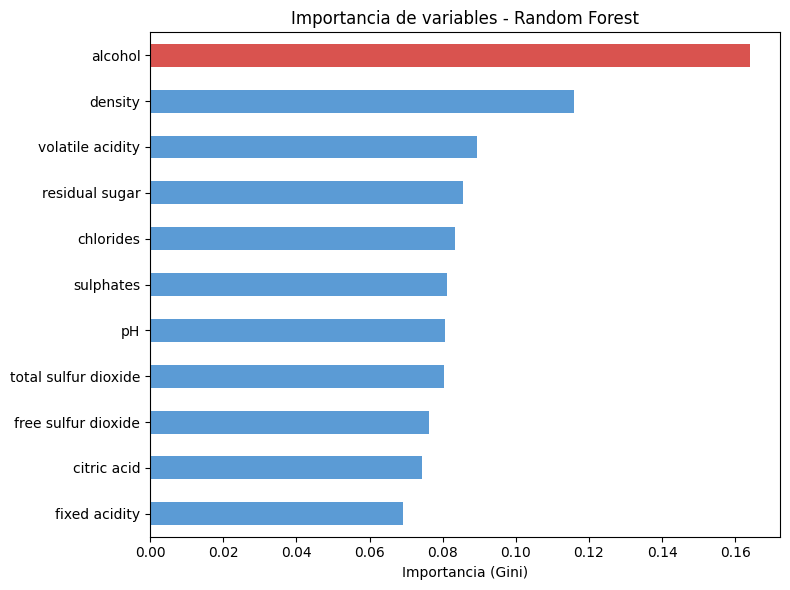

In [ ]:
# Importancia de variables - Random Forest
importancias_rf = pd.Series(model.feature_importances_, index=X.columns)
importancias_rf = importancias_rf.sort_values(ascending=True)

# Gráfico de importancia de variables - Random Forest
plt.figure(figsize=(8, 6))
colors = ['#d9534f' if v == importancias_rf.max() else '#5b9bd5' for v in importancias_rf]
importancias_rf.plot(kind='barh', color=colors)
plt.title('Importancia de variables - Random Forest')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

## Modelo Logistic Regression

In [ ]:
# Pipeline con escalado + Regresión Logística
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
log_pipeline.fit(X_train, y_train)

# Predicciones
log_model = log_pipeline  # alias para compatibilidad
y_pred_log = log_pipeline.predict(X_test)
y_pred_log_proba = log_pipeline.predict_proba(X_test)[:, 1]

In [31]:
# Métricas
print("Clasificación - Regresión Logística:\n")
print(classification_report(y_test, y_pred_log))

Clasificación - Regresión Logística:

              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1567
           1       0.61      0.26      0.36       383

    accuracy                           0.82      1950
   macro avg       0.72      0.61      0.63      1950
weighted avg       0.80      0.82      0.79      1950



In [32]:
# Matriz de confusión
print("Matriz de Confusión:\n")
print(confusion_matrix(y_test, y_pred_log))

Matriz de Confusión:

[[1504   63]
 [ 285   98]]


## Modelo XGboost

In [ ]:
# Crear y entrenar el modelo XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

In [36]:
# Métricas
print("Clasificación - XGBoost:\n")
print(classification_report(y_test, y_pred_xgb))

Clasificación - XGBoost:

              precision    recall  f1-score   support

           0       0.90      0.95      0.93      1567
           1       0.74      0.59      0.66       383

    accuracy                           0.88      1950
   macro avg       0.82      0.77      0.79      1950
weighted avg       0.87      0.88      0.87      1950



In [37]:
# Matriz de confusión
print("Matriz de Confusión:\n")
print(confusion_matrix(y_test, y_pred_xgb))

Matriz de Confusión:

[[1487   80]
 [ 157  226]]


In [38]:
# Presición
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.8784615384615385


### Importancia de variables — XGBoost

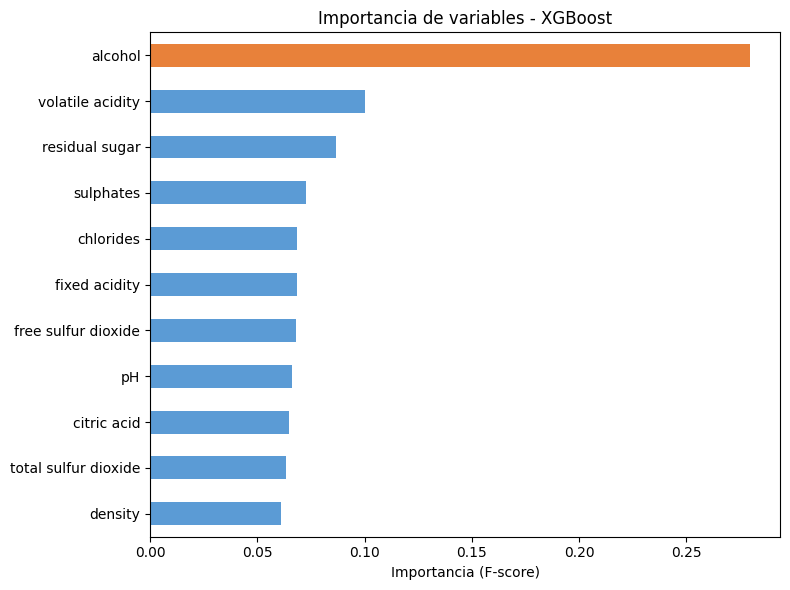

In [ ]:
# Importancia de variables - XGBoost
importancias_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)
importancias_xgb = importancias_xgb.sort_values(ascending=True)

# Gráfico de importancia de variables - XGBoost
plt.figure(figsize=(8, 6))
colors = ['#e8813a' if v == importancias_xgb.max() else '#5b9bd5' for v in importancias_xgb]
importancias_xgb.plot(kind='barh', color=colors)
plt.title('Importancia de variables - XGBoost')
plt.xlabel('Importancia (F-score)')
plt.tight_layout()
plt.show()

## Comparación de modelos

> **Nota:** el modelo `best_rf` del GridSearch reemplaza al Random Forest base en la comparación final y la curva ROC.

In [ ]:
# Búsqueda de hiperparámetros para Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=1, scoring='f1')
grid_search.fit(X_train, y_train)

print('Mejores parámetros:', grid_search.best_params_)
print(f'Mejor F1 en CV: {grid_search.best_score_:.4f}')

# Evaluar el mejor modelo sobre el test set
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_pred_best_rf_proba = best_rf.predict_proba(X_test)[:, 1]

print('\nClasificación - Random Forest (mejor modelo):\n')
print(classification_report(y_test, y_pred_best_rf))

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Mejor F1 en CV: 0.6059

Clasificación - Random Forest (mejor modelo):

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1567
           1       0.79      0.54      0.64       383

    accuracy                           0.88      1950
   macro avg       0.84      0.75      0.79      1950
weighted avg       0.88      0.88      0.87      1950



In [ ]:
# Random Forest (mejor modelo del GridSearch)
acc_rf = accuracy_score(y_test, y_pred_best_rf)
f1_rf = f1_score(y_test, y_pred_best_rf)
prec_rf = precision_score(y_test, y_pred_best_rf)
rec_rf = recall_score(y_test, y_pred_best_rf)

# Regresión Logística
acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)

# XGBoost
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)

# AUC
auc_rf  = roc_auc_score(y_test, y_pred_best_rf_proba)
auc_log = roc_auc_score(y_test, y_pred_log_proba)
auc_xgb = roc_auc_score(y_test, y_pred_xgb_proba)

# Resultados finales
print(f'Random Forest (opt) - Accuracy: {acc_rf:.2f}, F1: {f1_rf:.2f}, Precision: {prec_rf:.2f}, Recall: {rec_rf:.2f}, AUC: {auc_rf:.3f}')
print(f'Regresión Logística - Accuracy: {acc_log:.2f}, F1: {f1_log:.2f}, Precision: {prec_log:.2f}, Recall: {rec_log:.2f}, AUC: {auc_log:.3f}')
print(f'XGBoost             - Accuracy: {acc_xgb:.2f}, F1: {f1_xgb:.2f}, Precision: {prec_xgb:.2f}, Recall: {rec_xgb:.2f}, AUC: {auc_xgb:.3f}')

Random Forest (opt) - Accuracy: 0.88, F1: 0.64, Precision: 0.79, Recall: 0.54, AUC: 0.913
Regresión Logística - Accuracy: 0.82, F1: 0.36, Precision: 0.61, Recall: 0.26, AUC: 0.812
XGBoost             - Accuracy: 0.88, F1: 0.66, Precision: 0.74, Recall: 0.59, AUC: 0.902


### Curva ROC — Comparación de modelos

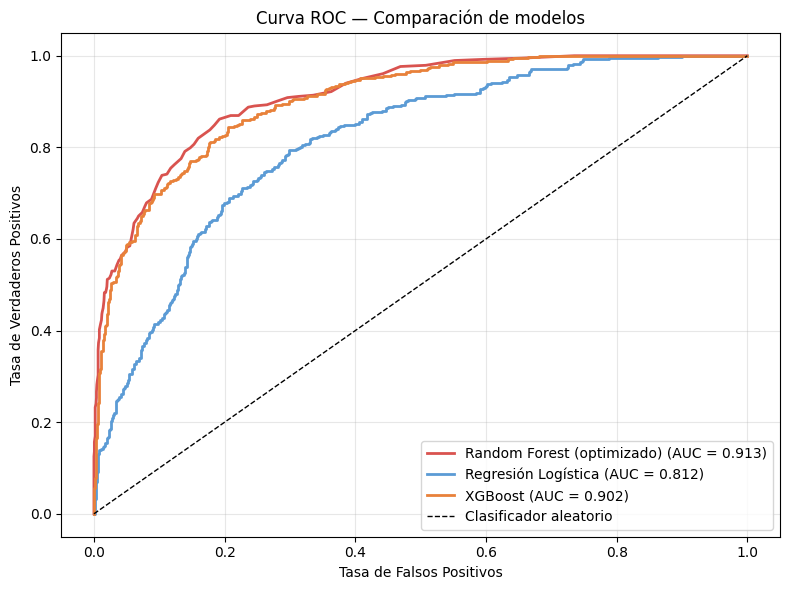

In [ ]:
# Curvas ROC para los tres modelos
fig, ax = plt.subplots(figsize=(8, 6))

modelos = [
    ('Random Forest (optimizado)', y_pred_best_rf_proba, '#d9534f'),
    ('Regresión Logística',        y_pred_log_proba,     '#5b9bd5'),
    ('XGBoost',                    y_pred_xgb_proba,     '#e8813a'),
]

for nombre, proba, color in modelos:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})', color=color, linewidth=2)

# Línea diagonal para referencia
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — Comparación de modelos')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusión

A partir del análisis exploratorio y de modelado realizados sobre el dataset de vinos tintos y blancos, se extraen las siguientes conclusiones:

**Sobre las hipótesis planteadas:**
- **Hipótesis 1 confirmada:** Existe una relación positiva entre el contenido de alcohol y la calidad percibida (correlación +0.44). Los boxplots y stripplots mostraron consistentemente que los vinos de mayor puntuación concentran sus observaciones en rangos de alcohol más elevados (11–13°).
- **Hipótesis 2 confirmada:** La acidez volátil presenta una correlación negativa con la calidad (−0.27). Niveles por encima de 0.8 g/L se asocian a puntuaciones menores, tanto en vinos tintos como blancos.
- **Hipótesis 3 confirmada:** Los modelos basados en árboles (Random Forest y XGBoost) superaron ampliamente a la Regresión Logística en todas las métricas, lo que refleja la naturaleza no lineal del problema.

**Sobre los modelos:**
Los tres modelos fueron entrenados sobre el mismo conjunto de datos balanceado, con Regresión Logística usando un pipeline de escalado (`StandardScaler`) para garantizar una comparación justa. El Random Forest optimizado mediante GridSearchCV y XGBoost obtuvieron los mejores resultados en Accuracy, F1-score y AUC-ROC. La curva ROC evidenció que ambos modelos de árboles tienen una capacidad discriminativa notablemente superior a la Regresión Logística. El análisis de importancia de variables identificó al **alcohol**, la **acidez volátil** y los **sulfatos** como los predictores de mayor peso en ambos modelos de árboles.

**Limitaciones y próximos pasos:**
El dataset presenta un desbalance de clases marcado: la gran mayoría de las muestras corresponden a calidades 5 y 6, mientras que las puntuaciones extremas (3 y 9) están subrepresentadas. Esto limita la capacidad de los modelos para predecir correctamente vinos de calidad excepcional o deficiente. Como próximos pasos se propone aplicar técnicas de balanceo (SMOTE o `class_weight='balanced'`), explorar modelos de ensamble más avanzados y, de estar disponibles, incorporar variables sensoriales o de proceso que podrían mejorar la capacidad predictiva.